# From structured numbers to real questions: the WaterTAP smoke test

Notebooks 01-03 trained on one structured task: three sensor readings in, a JSON diagnosis out.
`03` closed it at test exact match 0.985. The real MembraneClaw user does not write that. They write
*"after the storm the intake is at 36.5 g/kg, the pump goes 55 to 60 bar -- what's the lowest setting
that still gives us 4.3 m³/h under 420 mg/L?"*, and the deployed agent answers by running WaterTAP.

This notebook builds the task for that -- **natural-language questions answered with the two deployed
WaterTAP tools**, `simulate_ro` (one membrane unit) and `simulate_swro_system` (a whole plant, with
energy and cost), graded by code -- and runs the series' recipe on it: a seed, then PPO.

**On the 240 test questions, greedy:**

| policy | reward | decision right | proving simulations run | answer parses |
| --- | --- | --- | --- | --- |
| raw Qwen3.5-0.8B (dev) | 0.003 | 0.000 | 0.004 | 0.000 |
| the label seed | 0.833 | 0.812 | 0.867 | 0.996 |
| PPO, best of 500 steps | 0.844 | 0.838 | 0.854 | 0.975 |

**The seeds did almost all of it.** PPO's gain on test is +0.011 reward and +0.026 decisions, and it
is not significant (right only under PPO 21, only under the seed 15; McNemar p = 0.41). On
holdout_shift -- unseen phrasings, brinier and colder feed -- neither model holds up (reward 0.670
seed, 0.657 PPO). Of PPO's 39 wrong decisions on test, 22 follow correct simulations (mostly a scan
answered one setting off), 11 follow simulations that missed a proving point (mostly questions stated
in psi, °F, ft² or t/h: the conversion is done in the model's head), and 6 answers no longer parse.

- **The MembraneClaw benchmark (D1-D6, 117 cases) is evaluation-only.** No benchmark case, gold answer
  or rubric feeds the generator, a seed or the reward. The only code that opens it is the
  decontamination check: **0** generated prompts share an 8-word sequence with it, and **0** cases
  reuse a benchmark scenario's inputs.
- **Every gold answer is a real simulation.** The generator solves each scenario through the
  deployed server's own argument handling. The server on temur runs byte-identical code on the same
  package versions, and **12 of 12** sampled test-split gold results came back from it identical to the
  character.
- **1,800 questions in six families**, from a one-point limits check to choosing the cheapest of four
  membranes or the lowest-SEC plant configuration, 1 to 4 simulations each. Splits: train 1,200,
  dev 240, test 240, holdout_shift 120.
- **The reward pays per field, at the token that earns it** -- each call's arguments, the decision,
  the broken limits, each reported number -- and pays the decision in full only when the policy's own
  calls simulated the points that prove it. The reference episode scores **1.000** on all 1,800 cases;
  the best fixed answer without tools scores **at most 0.121** on any family, and the exact gold answer
  typed with no simulations at most **0.385**.

In [1]:
import collections, importlib.util, json, statistics as st, sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "04_natural_watertap.py").exists() else Path("experiments/notebooks/smoke_test35")
# This notebook's own module; the file name starts with a digit, so it is loaded by path. Scoring and
# checks are pure Python; nothing below needs WaterTAP or a GPU.
spec = importlib.util.spec_from_file_location("nw04", HERE / "04_natural_watertap.py")
nw = importlib.util.module_from_spec(spec)
sys.modules["nw04"] = nw
spec.loader.exec_module(nw)

splits = {s: nw.load_split(s) for s in nw.SPLITS}
checks = json.loads((HERE / "04_natural_watertap_checks.json").read_text())
print({s: len(c) for s, c in splits.items()}, "| families:", ", ".join(nw.FAMILIES))

{'train': 1200, 'dev': 240, 'test': 240, 'holdout_shift': 120} | families: ro_check, ro_scan_pressure, ro_scan_area, ro_membrane, swro_check, swro_option


## What the real benchmark asks, and why the smoke test is smaller

The benchmark is 117 workbooks in six domains, each a question, a gold reasoning trace, a six-step
rubric and a tool-efficiency rubric, graded by an LLM judge. Its questions are long and fully
specified -- parameter tables, candidate grids, required tasks -- and its reference solutions run
up to 30 simulations (the audit in `auto-evaluate/docs/BENCHMARK_AUDIT_D1_D6.md`). One `simulate_ro`
result is 877 tokens as the server returns it.

A 0.8B policy cannot start there. The smoke test keeps what makes the task real -- a user's own words
and units, a tool choice, arguments mapped from prose, limits checked against simulated numbers, a
decision -- and keeps each question to 1-4 simulations.

In [2]:
bench = sorted(nw.BENCH_DIR.glob("D*/*.xlsx"))
by_domain = collections.Counter(p.parent.name for p in bench)
print("benchmark workbooks:", len(bench), dict(sorted(by_domain.items())))
for label, first in (("question sheet", True), ("whole workbook", False)):
    n = [len(nw.read_xlsx_text(p, first_sheet_only=first)) for p in bench]
    print(f"characters per {label}: min {min(n):,}, median {int(st.median(n)):,}, max {max(n):,}")
ours = [len(c["prompt"]) for s in splits.values() for c in s]
print(f"characters per generated question: min {min(ours)}, median {int(st.median(ours))}, max {max(ours)}")

benchmark workbooks: 117 {'D1': 22, 'D2': 26, 'D3': 14, 'D4': 7, 'D5': 13, 'D6': 35}
characters per question sheet: min 2,069, median 20,161, max 63,382


characters per whole workbook: min 7,218, median 68,358, max 205,098
characters per generated question: min 347, median 542, max 808


## The tools are the deployed ones

The model sees the two tools exactly as the MCP server declares them (`04_natural_watertap_tools.json`,
dumped from the server itself): the docstring and a schema of parameter names and types, units only
in the names (`feed_nacl_mass_frac`, `p1_pressure_bar`). The system prompt is the deployed agent's
`SYSTEM_MESSAGE`, verbatim, plus one addition: an answer contract, so code can grade the answer.

Calls run through `ToolHost`, which does what FastMCP does -- validate with the tool's pydantic
model, drop unknown arguments, coerce numeric strings, wrap exceptions as `Error executing tool ...`
-- and then calls the server's own function, skipping its rate limiter (the deployed server allows 30
solves a minute; generating this set took 7,591). The deployed server runs on temur from byte-identical
`ro_model.py`, `swro_model.py` and `server.py` on the same watertap 1.7.0 / idaes 2.12.0 / pyomo 6.10.1.

In [3]:
decls = json.loads(nw.TOOLS_JSON.read_text())
for d in decls:
    f = d["function"]
    print(f"{f['name']}: {len(f['parameters']['properties'])} parameters; description starts {f['description'][:70]!r}")
print("\nsystem prompt matches agent/core.py SYSTEM_MESSAGE + contract:", checks["system_message_matches_agent"])
print("---\n" + nw.SYSTEM_PROMPT + "\n---")
for name in ("xcheck",):
    x = json.loads((HERE / f"04_natural_watertap_{name}.json").read_text())
    print(f"gold re-solved on the deployed server ({x['endpoint']}, {x['split']}): {x['identical']}/{x['n']} identical result text")

simulate_ro: 16 parameters; description starts 'Simulate a reverse osmosis module with the WaterTAP ReverseOsmosis0D m'
simulate_swro_system: 13 parameters; description starts 'Simulate and cost a *full seawater RO desalination plant*.\n\nUse this —'

system prompt matches agent/core.py SYSTEM_MESSAGE + contract: True
---
You are a capable assistant running on a local Qwen3.5 deployment. Use the provided tools when they give you a more accurate answer than reasoning alone; otherwise answer directly. When documents are attached, ground your answer in them and say so if the answer is not present.

Finish your reply with one JSON object and nothing after it:
{"decision": ..., "violations": [...], "values": {...}}
- "decision": the direct answer to the question. "pass" or "fail" when asked whether something meets its limits; otherwise the option or setting you recommend, written the way the user named it; null if none of the options works.
- "violations": when asked whether something meets

## Six kinds of question

| family | tool | the user asks | decision | simulations that prove it |
| --- | --- | --- | --- | --- |
| `ro_check` | `simulate_ro` | does this operating point meet our limits, and which fail? (sometimes after a disturbance, or for a proposed setpoint) | pass / fail + the broken limits | the point (1) |
| `ro_scan_pressure` | `simulate_ro` | the lowest (or highest) pump setting, from a range or a list, that meets every limit | a setting, or none | the answer and its failing neighbour (1-2) |
| `ro_scan_area` | `simulate_ro` | the smallest (or largest) membrane area that meets every limit | an area, or none | the same (1-2) |
| `ro_membrane` | `simulate_ro` | the cheapest of 2-4 quoted membranes (A, B) that meets every limit | a label, or none | every offer up to the answer (1-4) |
| `swro_check` | `simulate_swro_system` | does the plant meet its energy, cost, output and recovery targets? | pass / fail + the missed targets | the plant (1) |
| `swro_option` | `simulate_swro_system` | of 2-3 configurations (pump pressure, pump efficiency, pressure exchanger or pump-as-turbine), the lowest SEC or LCOW that meets the targets | a label, or none | every option (2-3) |

The scans rely on monotonicity: along a pressure or area scan every limit fails at one end only, so
a setting and the neighbour that fails prove the answer without simulating the rest (the generator
checks that the failures really are a prefix and a suffix). Each question also asks for one or two
numbers -- a permeate salinity, a specific energy -- at the chosen point.

One dev question per family:

In [4]:
seen = set()
for c in splits["dev"]:
    if c["family"] in seen:
        continue
    seen.add(c["family"])
    g = c["gold"]
    print(f"== {c['id']}  (unit level {c['level']}, {c['optimal_calls']} simulation(s) prove it)")
    print(c["prompt"])
    vals = {k: float(f"{v:.4g}") for k, v in g["values"].items()}
    print(f"-> decision {json.dumps(g['decision'])}, violations {g['violations']}, values {vals}\n")

== ro_check-dev-00000  (unit level 0, 1 simulation(s) prove it)
I'm looking at one of the RO trains and want a second opinion. We run it at 48.5 bar. Feed flow to the train is 4.07 kg/s. The train has 340 m² of membrane. Water temperature is 35 °C. The elements have a water permeability of 4.6e-12 m/s/Pa and a salt permeability of 2.3e-8 m/s. The cartridge filters were changed 28 days ago. Since the river plume moved off, feed salinity is a NaCl mass fraction of 0.0340 (it was a NaCl mass fraction of 0.0305). Flux must stay at or below 15 LMH. Product water must be under 250 ppm NaCl. The permeate target is 1 kg/s minimum. Salt rejection needs to be at least 99.5 %. Are we within every limit? Tell me which ones we break, if any. Also give me the water recovery and salt rejection.
-> decision "fail", violations ['performance.salt_rejection_pct', 'permeate.nacl_ppm'], values {'performance.water_recovery_pct': 30.55, 'performance.salt_rejection_pct': 99.15}

== ro_scan_pressure-dev-00001 

## Units, and how far every limit sits from the gold

The user states each quantity in their own unit. Level 0 is the tool's unit, level 1 a decimal shift
or relabel (g/kg, ‰, kPa, MPa, L/s, mg/L, %), level 2 a multiplicative conversion (t/h, psi, °F, ft²,
LMH/bar, gfd, m³/d, MGD, $ per 1,000 gallons). Every value is sampled on a round grid in the user's
unit and converted with an exact factor, so the gold is unique; conversions that need a density
(m³/h of seawater into kg/s) are never used.

Arguments are graded within 0.5%. So that a call that is right within that tolerance can never flip
a gold pass/fail, every limit sits at least 2% from every simulated value it is compared with (0.1%
for salt rejection, which barely moves). Measured: the worst output change for a 0.5% error in any
one input is below the margin on both tools.

In [5]:
el = json.loads((HERE / "04_natural_watertap_elasticity.json").read_text())
print(f"scenarios per tool: {el['scenarios']}; input error +-{el['arg_tol']:.1%}")
for tool, row in el["worst_by_metric"].items():
    for path, worst in row.items():
        print(f"  {tool:22} {path:34} worst change {worst:6.2%}   margin {el['margin'][path]:.1%}")
print("\nunit level of the cases (highest level any quantity in the question uses):")
for s, cs in splits.items():
    print(f"  {s:14}", dict(sorted(collections.Counter(c['level'] for c in cs).items())))

scenarios per tool: {'simulate_ro': 12, 'simulate_swro_system': 12}; input error +-0.5%
  simulate_ro            permeate.flow_kg_s                 worst change  1.34%   margin 2.0%
  simulate_ro            permeate.nacl_ppm                  worst change  1.34%   margin 2.0%
  simulate_ro            performance.water_recovery_pct     worst change  1.34%   margin 2.0%
  simulate_ro            performance.salt_rejection_pct     worst change  0.02%   margin 0.1%
  simulate_ro            flux.water_LMH                     worst change  1.34%   margin 2.0%
  simulate_swro_system   costing.specific_energy_kWh_m3     worst change  0.52%   margin 2.0%
  simulate_swro_system   costing.LCOW_usd_m3                worst change  0.42%   margin 2.0%
  simulate_swro_system   performance.product_flow_m3_s      worst change  0.73%   margin 2.0%
  simulate_swro_system   performance.system_recovery_pct    worst change  0.73%   margin 2.0%

unit level of the cases (highest level any quantity in the questi

## The reward

The answer contract asks the model to end with `{"decision": ..., "violations": [...], "values": {...}}`,
values keyed by the result field they come from (`permeate.nacl_ppm`). Six components; those that do
not apply to a question (violations outside the pass/fail families, values when no option works) drop
out and the rest are renormalised.

| component | weight | what earns it | where the credit lands |
| --- | --- | --- | --- |
| calls | 0.25 | per call: right tool, and the share of the scenario's arguments right within 0.5% after unit conversion, minus 0.25 for each argument the user never gave (unless it equals the tool default) or the tool does not have; averaged over the calls | each call's end |
| decision | 0.35 | the right pass/fail, setting or label (a setting may be written in the user's unit or the tool's) | the decision value |
| violations | 0.10 | pass/fail families: F1 of the broken limits against the truth | the violations list |
| values | 0.20 | each requested number within 1.5% of the simulation | each number |
| format | 0.05 | the object parses, has the three keys, and nothing follows it | the closing brace |
| efficiency | 0.05 | proven and correct: min(1, simulations needed / calls made) | the closing brace |

**The evidence gate.** A call *covers* a scenario point when it gets every argument right, sets nothing
else, and runs. The decision and violations are paid in full only if the calls covered every point
that proves the answer; otherwise at 0.3. The gate is what makes guessing unprofitable: with a choice
among a few settings, "always say the highest" or a coin-flip pass/fail would otherwise be a cheap
local optimum.

In [6]:
rows, worst_credit, oracle_min = collections.defaultdict(list), 0.0, 1.0
for s, cs in splits.items():
    for c in cs:
        b = nw.baselines(c)
        rows[c["family"]].append(b)
        sc = nw.score(c, nw.oracle_calls(c), json.dumps(nw.gold_answer(c)))
        worst_credit = max(worst_credit, abs(sum(a for _, a in sc["credits"]) - sc["total"]))
        oracle_min = min(oracle_min, sc["total"])
print(f"reference episode, all {sum(len(v) for v in rows.values())} cases: min total {oracle_min:.4f}; "
      f"max |sum of credits - total| {worst_credit:.1e}\n")
cols = ["oracle", "oracle_plus_2_calls", "proof_calls_wrong_decision", "gold_answer_no_calls", "best_no_call_guess"]
print(f"{'family':17}" + "".join(f"{c:>28}" for c in cols))
for fam in nw.FAMILIES:
    bs = rows[fam]
    mean = lambda k: st.mean(b[k] for b in bs)  # noqa: E731
    guess = max(st.mean(b[k] for b in bs) for k in bs[0] if k.startswith("no_calls"))
    print(f"{fam:17}" + "".join(f"{v:>28.3f}" for v in [mean(c) for c in cols[:-1]] + [guess]))

reference episode, all 1800 cases: min total 1.0000; max |sum of credits - total| 0.0e+00

family                                 oracle         oracle_plus_2_calls  proof_calls_wrong_decision        gold_answer_no_calls          best_no_call_guess
ro_check                                1.000                       0.967                       0.600                       0.385                       0.120
ro_scan_pressure                        1.000                       0.965                       0.525                       0.353                       0.095
ro_scan_area                            1.000                       0.966                       0.533                       0.364                       0.091
ro_membrane                             1.000                       0.970                       0.535                       0.366                       0.095
swro_check                              1.000                       0.967                       0.600                  

What the columns say, all splits together. The reference episode (the proving simulations, then the
gold answer) earns 1.000. Two redundant calls cost 3-4% through efficiency. Right simulations with a
wrong decision keep about half: the calls and the numbers were real work. The exact gold answer
typed without a single simulation earns at most 0.385 -- the gate holds the decision at 0.3 and the
calls earn nothing -- and the best fixed guess without tools (always "pass", always the first option,
always "none") earns at most 0.121.

A few single calls, to show how arguments are graded (`ro_scan_pressure`, the first proving point).
An argument the tool does not have is dropped by the server, so the simulation still covers the point,
but the call loses the same 0.25 as a stray one:

In [7]:
c = next(c for c in splits["dev"] if c["family"] == "ro_scan_pressure")
ref = nw.oracle_calls(c)[0]
p = ref["arguments"]["feed_pressure_bar"]
trials = {
    "as the reference": ref,
    "pressure 2% off": dict(ref, arguments=dict(ref["arguments"], feed_pressure_bar=p * 1.02)),
    "pressure 0.3% off": dict(ref, arguments=dict(ref["arguments"], feed_pressure_bar=p * 1.003)),
    "adds pressure_drop_bar=1": dict(ref, arguments=dict(ref["arguments"], pressure_drop_bar=1.0)),
    "adds ph=7.8 (no such argument)": dict(ref, arguments=dict(ref["arguments"], ph=7.8)),
    "the plant tool instead": dict(ref, name=nw.SWRO),
}
for name, call in trials.items():
    f, cov = nw.call_fidelity(c, call)
    print(f"  {name:32} fidelity {f:.3f}   covers {cov}")
fenced = "Here you go:\n```json\n" + json.dumps(nw.gold_answer(c)) + "\n```"
print("\n  answer inside a ```json fence:", nw.score(c, nw.oracle_calls(c), fenced)["components"])

  as the reference                 fidelity 1.000   covers p3
  pressure 2% off                  fidelity 0.833   covers None
  pressure 0.3% off                fidelity 1.000   covers p3
  adds pressure_drop_bar=1         fidelity 0.750   covers None
  adds ph=7.8 (no such argument)   fidelity 0.750   covers p3
  the plant tool instead           fidelity 0.000   covers None

  answer inside a ```json fence: {'calls': 1.0, 'decision': 1.0, 'values': 1.0, 'format': 0.0, 'efficiency': 1.0}


## Balance: every answer is said

`03`'s lesson was that a label the policy never produces cannot be learned. The generator fixes each
case's target answer before it draws anything else -- none with probability 0.2 (0.15 for plant
options), otherwise a position spread evenly over the options -- and redraws the scenario, not the
target, until the thresholds can carry it. (Redrawing the target instead lets the answers that are
easiest to fit take over.) On train:

In [8]:
for fam in nw.FAMILIES:
    cs = [c for c in splits["train"] if c["family"] == fam]
    dec = collections.Counter(nw.decision_label(c) for c in cs)
    calls = collections.Counter(c["optimal_calls"] for c in cs)
    print(f"  {fam:17} n={len(cs)}  simulations needed {dict(sorted(calls.items()))}")
    print(f"  {'':17} decisions {dict(dec.most_common())}")

  ro_check          n=200  simulations needed {1: 200}
                    decisions {'fail': 103, 'pass': 97}
  ro_scan_pressure  n=200  simulations needed {1: 93, 2: 107}
                    decisions {'none': 52, '1/4': 22, '3/4': 21, '3/3': 18, '4/4': 16, '2/3': 15, '2/4': 10, '1/5': 10, '2/5': 9, '3/5': 8, '1/3': 7, '5/5': 6, '4/5': 6}
  ro_scan_area      n=200  simulations needed {1: 83, 2: 117}
                    decisions {'none': 38, '4/4': 21, '1/4': 20, '3/4': 17, '2/4': 17, '1/5': 14, '3/3': 14, '1/3': 14, '2/3': 12, '5/5': 10, '4/5': 9, '3/5': 8, '2/5': 6}
  ro_membrane       n=200  simulations needed {1: 61, 2: 71, 3: 56, 4: 12}
                    decisions {'A': 61, 'B': 60, 'C': 42, 'none': 30, 'D': 7}
  swro_check        n=200  simulations needed {1: 200}
                    decisions {'fail': 118, 'pass': 82}
  swro_option       n=200  simulations needed {2: 78, 3: 122}
                    decisions {'B': 76, 'A': 56, 'C': 42, 'none': 26}


## Decontamination

Two tests against all 117 benchmark workbooks (every sheet: questions, gold answers, rubrics). Text:
any 8-word sequence shared with a generated prompt. Scenarios: a case whose core inputs (feed flow,
salinity, area and pressure for a unit; flow, TDS and pump pressure for a plant) all appear, at four
significant figures, in one workbook. The splits share no scenario with each other either.

In [9]:
d = checks["decontamination"]
print(f"benchmark 8-grams: {d['benchmark_8grams']:,}; generated prompts sharing any: {d['prompts_with_any_8gram']}")
print(f"cases reusing a benchmark scenario's core inputs: {d['cases_reusing_a_benchmark_scenario']} "
      f"(a workbook holds {d['numbers_per_workbook_median']} distinct numbers at the median)")
print("scenarios shared between splits:", checks["cross_split_scenarios"])
print("duplicate prompts:", checks["duplicate_prompts"])

benchmark 8-grams: 105,943; generated prompts sharing any: 0
cases reusing a benchmark scenario's core inputs: 0 (a workbook holds 85 distinct numbers at the median)
scenarios shared between splits: {'dev&train': 0, 'dev&test': 0, 'dev&holdout_shift': 0, 'test&train': 0, 'holdout_shift&train': 0, 'holdout_shift&test': 0}
duplicate prompts: 0


## The episode budget

What a 0.8B policy has to hold: the system prompt, both tool declarations and the question before it
writes anything, then 877 tokens for every simulation it runs. Measured with the policy's tokenizer
on the reference episodes of dev:

In [10]:
import warnings
warnings.filterwarnings("ignore")
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("Qwen/Qwen3.5-0.8B")

def messages(case, calls=(), answer=None):
    msgs = [{"role": "system", "content": nw.SYSTEM_PROMPT}, {"role": "user", "content": case["prompt"]}]
    for call in calls:
        msgs.append({"role": "assistant", "content": "", "tool_calls": [{"type": "function", "function": {
            "name": call["name"], "arguments": call["arguments"]}}]})
        msgs.append({"role": "tool", "content": call["result"]})
    if answer is not None:
        msgs.append({"role": "assistant", "content": json.dumps(answer)})
    return msgs

def n_tokens(msgs, gen=False):
    text = tok.apply_chat_template(msgs, tools=decls, tokenize=False, add_generation_prompt=gen,
                                   enable_thinking=False)
    return len(tok(text, add_special_tokens=False)["input_ids"])

per_family = collections.defaultdict(lambda: ([], []))
for c in splits["dev"]:
    prompt = n_tokens(messages(c), gen=True)
    full = n_tokens(messages(c, nw.oracle_calls(c), nw.gold_answer(c)))
    per_family[c["family"]][0].append(prompt)
    per_family[c["family"]][1].append(full)
c0 = splits["dev"][0]
with_tools = n_tokens(messages(c0), gen=True)
text = tok.apply_chat_template(messages(c0), tokenize=False, add_generation_prompt=True, enable_thinking=False)
no_tools = len(tok(text, add_special_tokens=False)["input_ids"])
question = len(tok(c0["prompt"], add_special_tokens=False)["input_ids"])
print(f"{c0['id']}: {with_tools} prompt tokens = {with_tools - no_tools} for the two tool declarations "
      f"+ {no_tools - question} system prompt and template + {question} for the question\n")
print(f"{'family':17} {'prompt tokens':>14} {'reference episode tokens (median / max)':>40}")
for fam in nw.FAMILIES:
    pr, full = per_family[fam]
    print(f"{fam:17} {int(st.median(pr)):>14} {int(st.median(full)):>24} / {max(full)}")

ro_check-dev-00000: 2083 prompt tokens = 1649 for the two tool declarations + 209 system prompt and template + 225 for the question

family             prompt tokens  reference episode tokens (median / max)
ro_check                    2017                     3106 / 3198
ro_scan_pressure            2037                     3160 / 4265
ro_scan_area                2033                     4037 / 4254
ro_membrane                 2089                     4209 / 6600
swro_check                  2002                     2769 / 2850
swro_option                 2025                     4125 / 4444


The two tool declarations are most of what the policy reads before it writes. A reference episode is
five to ten times as long as the 100-640 tokens of `01`-`03`'s, and most of that length is simulator
output, which is context, not something the policy writes or is trained on.

## The harness

An episode runs the way the deployed agent would run it. The policy writes a turn; every
`<tool_call>` block in it is parsed from Qwen3.5's XML form, its arguments typed by the tool's schema
as the deployed tool-call parser types them; the calls run through `ToolHost` in worker processes
under `.venv-watertap` (the training venv has no WaterTAP), behind a cache, since the simulators are
deterministic; a turn's results come back as one user turn and the policy writes again. A turn
without calls is the answer. Up to 8 simulations and 6 tool rounds per episode. The turn protocol
is `03`'s: only `<|im_end|>` ends a turn, and every evaluation here stops the answer turn where its
JSON object closes.

Two checks on 60 dev reference episodes: the episode built by token concatenation is the chat
template's own rendering, token for token; and the workers reproduce every gold result byte for byte.

In [11]:
hc = json.loads((HERE / "04_natural_watertap_harness_checks.json").read_text())
print(f"reference episodes checked: {hc['n']} ({hc['split']})")
print(f"  tool calls that survive the XML round trip:          {hc['calls_parse_roundtrip']}/{hc['n']}")
print(f"  episodes whose token ids equal the template's:        {hc['token_ids_equal_template']}/{hc['n']}")
print(f"  worker results identical to gold (same arguments):    {hc['pool_results_identical_to_gold_exact_args']}/{hc['pool_calls']}")
print(f"  reference reward through the workers: min {hc['reference_score_through_pool_min']:.3f}")
RUNS = nw.RUNS


def report(path, split):
    return nw.episode_report(path, split)


def rows_of(path):
    return [json.loads(line) for line in Path(path).read_text().splitlines()]

reference episodes checked: 60 (dev)
  tool calls that survive the XML round trip:          60/60
  episodes whose token ids equal the template's:        60/60
  worker results identical to gold (same arguments):    100/100
  reference reward through the workers: min 1.000


## The raw model cannot start

Raw Qwen3.5-0.8B, greedy, on all 240 dev questions, 1,536 tokens of its own per episode:

In [12]:
raw_path = RUNS / "raw" / "dev-T0.episodes.jsonl"
raw = rows_of(raw_path)
r0 = report(raw_path, "dev")["all:"]
names = collections.Counter(c["name"] for r in raw for c in r["calls"])
real = [c for r in raw for c in r["calls"] if c["name"] in nw.TOOLS]
print(f"reward {r0['reward']:.3f}; answers that parse {r0['answer_found']:.3f}; episodes that call a tool "
      f"{sum(bool(r['calls']) for r in raw)}/{len(raw)}")
print("tools it called:", dict(names.most_common()))
print(f"calls to a real tool that ran: {sum(not c['error'] for c in real)}/{len(real)}")
print(f"out of tokens {r0['truncated']:.2f}; still calling when the rounds ran out {r0['unanswered']:.2f}")

reward 0.003; answers that parse 0.000; episodes that call a tool 188/240
tools it called: {'simulate_ro_system': 875, 'simulate_swro_system': 179, 'simulate_ro': 33}
calls to a real tool that ran: 7/212
out of tokens 0.56; still calling when the rounds ran out 0.43


Four out of five calls go to `simulate_ro_system`, a tool that does not exist -- the two real names
run together. The calls to real tools pass values in the user's units (6,050 kPa as bar, 39.2 g/kg
as a mass fraction) or set parameters to 0, and the model repeats them turn after turn instead of
answering. Nothing a policy gradient could reweight.

## A seed that does not know the answer

A seed learns from reference episodes, and they must be ones a policy could produce without knowing
the answer. The simulations that *prove* a scan's answer depend on where the answer is, so an episode
that runs only those would teach the model to guess the boundary. The reference strategy is blind:
**simulate every candidate in one turn, then answer** -- one comparison line per candidate, then the
JSON object. It costs only efficiency, and pruning is left for PPO to find.

The seed is supervised on the scaffolding and leaves the content to PPO -- `02`'s split, where the
seed teaches the tool and PPO the task:

| labelled | left to PPO | measured when it was not labelled |
| --- | --- | --- |
| the calls turn and its `<|im_end|>` | -- | the raw model, above |
| each comparison line's skeleton (candidate, field names, operators) and its verdicts (`meets`/`breaks`, `pass`/`fail`) | every simulated value and every limit | with the verdicts left out, the seed wrote `->` where they go on 719 of 720 greedy dev answers and repeated the line to the token budget on up to 22% of them |
| the JSON's syntax: braces, keys, quotes, brackets, commas | the decision's text, each violation's text, each number | with the decision's quotes left out, `"decision": C` (which does not parse) on 12 of 40 plant-option answers |

In [13]:
from transformers import AutoTokenizer
import re
refs = rows_of(nw.DATA / "train_reference.jsonl")
rw = [r["reward"] for r in refs]
print(f"blind reference episodes on train: {len(refs)}, reward mean {st.mean(rw):.3f}, min {min(rw):.3f}")
tok = AutoTokenizer.from_pretrained(nw.MODEL, padding_side="left")
train_cases = {c["id"]: c for c in splits["train"]}
ref = next(r for r in refs if train_cases[r["id"]]["family"] == "ro_scan_pressure"
           and train_cases[r["id"]]["gold"]["decision"] is not None)
ids, lab = nw.seed_example(train_cases[ref["id"]], ref, tok, label="scaffold", reasoning=True)
n = len(tok(ref["answer_reasoned"], add_special_tokens=False).input_ids) + 1
shown = "".join(tok.decode([t]) if l != -100 else "·" for t, l in zip(ids[0][-n:].tolist(), lab[0][-n:].tolist()))
print("\nits answer turn as the seed sees it (· = left to PPO):\n" + re.sub("·+", "·", shown))

blind reference episodes on train: 1200, reward mean 0.986, min 0.943



its answer turn as the seed sees it (· = left to PPO):
5.80 MPa: flux.water_LMH · meets <= ·; permeate.flow_kg_s · breaks >= ·; performance.salt_rejection_pct · meets >= · -> fail
6.00 MPa: flux.water_LMH · meets <= ·; permeate.flow_kg_s · breaks >= ·; performance.salt_rejection_pct · meets >= · -> fail
6.20 MPa: flux.water_LMH · meets <= ·; permeate.flow_kg_s · meets >= ·; performance.salt_rejection_pct · meets >= · -> pass

{"decision": "·", "violations": [], "values": {"performance.salt_rejection_pct": ·, "flux.water_LMH": ·}}<|im_end|>


## The label seed: every answer has to be said

That seed passes every greedy gate -- answers parse 1.000, right tool 1.000, calls erroring 0,
proving simulations 0.883, nothing truncated. Sampled, it still cannot be trained on: in every
choice family it never says "none". That is structural. The opening quote of a string decision is
scaffolding, labelled on every record whose answer is an option, and `null` has no quote; inside the
quotes, it writes the verdict word it has just been writing. A policy gradient reweights what the
policy samples (`03`), so none of those answers could be learned.

`03`'s lever: the **label seed** -- the same seed, with the decision itself labelled on *k* train
records per answer class (membrane A-D and none, plant option A-C and none, scans "a setting" and
none; the pass/fail families are left alone, both answers are already said). Right answers at T=1,
two samples per dev question:

family            answer         k=0       k=2       k=4       k=8
ro_check          fail       42/44     41/44     39/44     39/44  
ro_check          pass       28/36     30/36     32/36     30/36  
swro_check        fail       33/34     32/34     34/34     33/34  
swro_check        pass       34/46     39/46     40/46     39/46  
ro_membrane       A           2/22     18/22     19/22     18/22  
ro_membrane       B           5/26     19/26     21/26     22/26  
ro_membrane       C           2/10      9/10     10/10     10/10  
ro_membrane       none        0/22     20/22     19/22     18/22  
swro_option       A           4/20     17/20     18/20     18/20  
swro_option       B          13/34     25/34     27/34     27/34  
swro_option       C           4/18     11/18     11/18     10/18  
swro_option       none        0/8       8/8       8/8       8/8   
ro_scan_area      setting    11/68     41/68     40/68     41/68  
ro_scan_area      none        0/12     10/12     11/12     12/

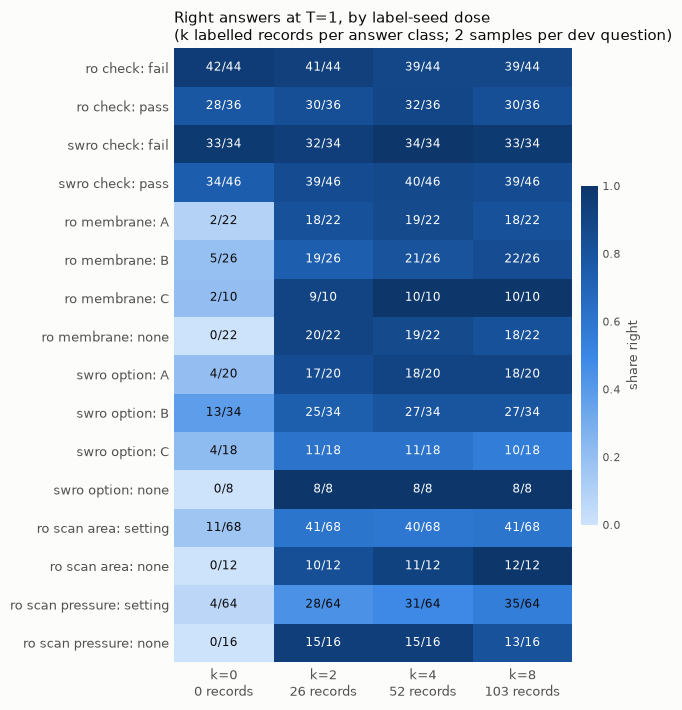

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

dev_cases = {c["id"]: c for c in splits["dev"]}


def answer_class(c):
    return nw.decision_class(c) or c["gold"]["decision"]


doses = [("k=0", RUNS / "seed-verdict2"), ("k=2", RUNS / "label-seed-pc2"),
         ("k=4", RUNS / "label-seed-pc4"), ("k=8", RUNS / "label-seed-pc8")]
records = {name: len(json.loads((d / "config.json").read_text()).get("label_case_ids", [])) for name, d in doses}
recall = {}
for name, d in doses:
    rec = collections.defaultdict(lambda: [0, 0])
    for r in rows_of(d / "epoch3" / "dev-T1-x2-stop.episodes.jsonl"):
        c = dev_cases[r["id"]]
        rec[(c["family"], answer_class(c))][1] += 1
        rec[(c["family"], answer_class(c))][0] += r["score"]["decision_correct"]
    recall[name] = rec
order = [("ro_check", "fail"), ("ro_check", "pass"), ("swro_check", "fail"), ("swro_check", "pass"),
         ("ro_membrane", "A"), ("ro_membrane", "B"), ("ro_membrane", "C"), ("ro_membrane", "none"),
         ("swro_option", "A"), ("swro_option", "B"), ("swro_option", "C"), ("swro_option", "none"),
         ("ro_scan_area", "setting"), ("ro_scan_area", "none"), ("ro_scan_pressure", "setting"),
         ("ro_scan_pressure", "none")]
print(f"{'family':17} {'answer':8}" + "".join(f"{n:>10}" for n, _ in doses))
for key in order:
    print(f"{key[0]:17} {key[1]:8}" + "".join(f"{recall[n][key][0]:>5}/{recall[n][key][1]:<4}" for n, _ in doses))
print()
for name, d in doses:
    o = json.loads((d / "epoch3" / "dev-T1-x2-stop.json").read_text())["overall"]
    print(f"  {name} ({records[name]:3} labelled records): sampled reward {o['reward']:.3f}, decision "
          f"{o['decision_correct']:.3f}, proving simulations {o['evidence']:.3f}")

# Figure: right answers at T=1 per answer class and dose (sequential blue: one hue, light -> dark).
blues = LinearSegmentedColormap.from_list("blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
M = [[recall[n][k][0] / recall[n][k][1] for n, _ in doses] for k in order]
fig, ax = plt.subplots(figsize=(6.6, 7.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
im = ax.imshow(M, cmap=blues, vmin=0, vmax=1, aspect="auto")
for i, key in enumerate(order):
    for j, (n, _) in enumerate(doses):
        ax.text(j, i, f"{recall[n][key][0]}/{recall[n][key][1]}", ha="center", va="center", fontsize=8.5,
                color="#ffffff" if M[i][j] > 0.55 else "#0b0b0b")
ax.set_xticks(range(len(doses)), [f"{n}\n{records[n]} records" for n, _ in doses], fontsize=9, color="#52514e")
ax.set_yticks(range(len(order)), [f"{f.replace('_', ' ')}: {a}" for f, a in order], fontsize=9, color="#52514e")
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("Right answers at T=1, by label-seed dose\n(k labelled records per answer class; 2 samples per dev question)",
             fontsize=10.5, color="#0b0b0b", loc="left")
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, colors="#52514e", length=0)
cb.set_label("share right", fontsize=9, color="#52514e")
fig.tight_layout()
fig.savefig(HERE / "04_natural_watertap_dose.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

At *k* = 2 -- 26 labelled records out of 1,200 -- every answer class is said, most of them right:
"none" goes from 0 right to 20/22, 8/8, 10/12 and 15/16. The pass/fail families are unchanged and the
calls hold. Four and eight records per class add little. PPO starts from *k* = 2, the weakest dose
that brings every answer within reach.

## PPO

| setting | value | from |
| --- | --- | --- |
| start | the label seed, *k* = 2, epoch 3 | above |
| critic | value head on hidden layer 23, lr 9.19e-4, warm-started at 0.807 (the seed's own sampled dev reward); 25 steps with the actor frozen | `02`'s choices, not re-probed on this task; the critic gate is the check |
| actor | LoRA r16, lr 1e-5, 4 inner epochs, clip 0.2; 8 train questions per step at T=1; gamma 1, lambda 0.95 | `03` |
| what the actor moves | the calls turn, and in the answer only its content: numbers, verdicts, the decision, the violations. The `<|im_end|>` that ends a turn and the scaffolding the seed learned are out of its loss | `03`'s frozen scaffolding |
| stabilisers | Adam eps 1e-6; KL 0.01 to the seed in the reward; answers stopped at their closing brace | `03` |
| gates | a **tool gate** (new): sampled call fidelity below 0.90 over 10 steps stops the run -- the seed taught the calls, and PPO must not lose them; `03`'s critic and no-regression gates; convergence: 8 evaluations without a new best, one evaluation of 120 dev questions every 25 steps | `03`, and new |

{'stopped_at': 500, 'reason': 'converged: 8 evaluations without beating 0.8774 (step 300)', 'best_step': 300, 'best_reward': 0.8773546075837743}

 step  reward  decision  proving  violations  values  parses  critic - clock
    0   0.833     0.783    0.908       0.907   0.811   1.000               -
   25   0.833     0.783    0.908       0.907   0.811   1.000          +0.062
   50   0.813     0.742    0.925       0.739   0.796   1.000          +0.071
   75   0.849     0.808    0.917       0.903   0.825   1.000          +0.057
  100   0.821     0.767    0.883       0.831   0.806   1.000          +0.038
  125   0.836     0.817    0.883       0.875   0.796   1.000          +0.035
  150   0.856     0.850    0.883       0.922   0.825   0.992          +0.033
  175   0.843     0.842    0.867       0.908   0.806   0.992          +0.034
  200   0.834     0.817    0.842       0.884   0.801   0.958          +0.053
  225   0.838     0.825    0.892       0.894   0.772   0.983          +0.070
  250  

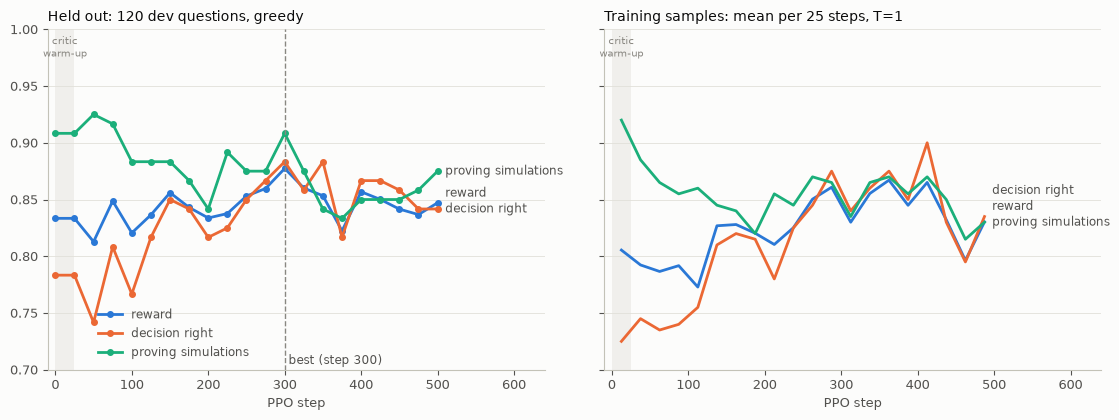

In [15]:
run = RUNS / "ppo-s0"
evals = rows_of(run / "eval.jsonl")
metrics = rows_of(run / "metrics.jsonl")
ending = json.loads((run / "ending.json").read_text())
print(ending)
print(f"\n{'step':>5} {'reward':>7} {'decision':>9} {'proving':>8} {'violations':>11} {'values':>7} {'parses':>7} {'critic - clock':>15}")
for e in evals:
    c = e["components"]
    crit = e["critic_residual_median"]
    print(f"{e['step']:>5} {e['reward']:>7.3f} {e['decision_correct']:>9.3f} {e['evidence']:>8.3f} {c['violations']:>11.3f} "
          f"{c['values']:>7.3f} {e['answer_found']:>7.3f} {'-' if crit is None else f'{crit:+.3f}':>15}")
win = []
for a in range(0, ending["stopped_at"], 25):
    w = [r for r in metrics if a <= r["step"] < a + 25]
    win.append((a + 12.5, st.mean(r["reward_mean"] for r in w), st.mean(r["decision_correct"] for r in w),
                st.mean(r["evidence"] for r in w)))
ahead = [r for r in metrics if r["step"] >= 25 and r["value_ev"] is not None and r["value_ev_position"] is not None]
print(f"\nactor steps where the critic explains the return better than the position clock: "
      f"{sum(r['value_ev'] > r['value_ev_position'] for r in ahead)}/{len(ahead)}")
print(f"KL to the seed per token, steps 250-499: {st.mean(r['kl_mean'] for r in metrics if r['step'] >= 250):.4f}")

def dodge(ys, gap=0.014):
    # Label positions for line ends: the ends' own heights, pushed apart to at least `gap`.
    order_ = sorted(range(len(ys)), key=lambda i: ys[i])
    out = list(ys)
    for a, b in zip(order_, order_[1:]):
        out[b] = max(out[b], out[a] + gap)
    return out


# Figure: held-out evaluations (left) and sampled training windows (right), one shared scale.
series = [("reward", "#2a78d6"), ("decision right", "#eb6834"), ("proving simulations", "#1baf7a")]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True, facecolor="#fcfcfb")
for ax in axes:
    ax.set_facecolor("#fcfcfb")
    ax.axvspan(0, 25, color="#f0efec", lw=0)
    ax.grid(axis="y", color="#e1e0d9", lw=0.6)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#c3c2b7")
    ax.tick_params(colors="#52514e", labelsize=9)
    ax.set_xlabel("PPO step", fontsize=9, color="#52514e")
    ax.text(12.5, 0.995, "critic\nwarm-up", ha="center", va="top", fontsize=7.5, color="#898781")
    ax.set_xlim(-10, 640)
xs = [e["step"] for e in evals]
cols = [[e["reward"] for e in evals], [e["decision_correct"] for e in evals], [e["evidence"] for e in evals]]
for (label, color), ys in zip(series, cols):
    axes[0].plot(xs, ys, color=color, lw=2, marker="o", ms=4, label=label)
for (label, _), y in zip(series, dodge([ys[-1] for ys in cols])):
    axes[0].text(xs[-1] + 10, y, label, color="#52514e", fontsize=8.5, va="center")
axes[0].axvline(ending["best_step"], color="#898781", lw=1, ls="--")
axes[0].text(ending["best_step"] + 5, 0.705, f"best (step {ending['best_step']})", color="#52514e", fontsize=8.5)
axes[0].set_title("Held out: 120 dev questions, greedy", fontsize=10, color="#0b0b0b", loc="left")
wx = [w[0] for w in win]
for (label, color), k in zip(series, (1, 2, 3)):
    axes[1].plot(wx, [w[k] for w in win], color=color, lw=2, label=label)
for (label, _), y in zip(series, dodge([win[-1][k] for k in (1, 2, 3)])):
    axes[1].text(wx[-1] + 10, y, label, color="#52514e", fontsize=8.5, va="center")
axes[1].set_title("Training samples: mean per 25 steps, T=1", fontsize=10, color="#0b0b0b", loc="left")
axes[0].set_ylim(0.70, 1.0)
axes[0].legend(loc="lower left", fontsize=8.5, frameon=False, labelcolor="#52514e", bbox_to_anchor=(0.08, 0.0))
fig.tight_layout()
fig.savefig(HERE / "04_natural_watertap_curves.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

The held-out reward dips at step 50, climbs to its best at step 300 and stays between 0.82 and 0.86
after it; the run stopped itself at step 500 on convergence. In the training samples the decisions
rise from about 0.74 to about 0.86 while the share of episodes whose simulations cover the proving
points drifts down. The critic is ahead of the position clock on almost every actor step, and KL to
the seed stays near 0.02 per token.

The best checkpoint was chosen on the 120 dev questions it is scored on above. The held-out splits
below are the honest numbers.

## Held out

The best checkpoint and the seed alone, greedy, answers stopped at their closing brace:

In [16]:
import math


def mcnemar(b, c):
    n = b + c
    return 1.0 if n == 0 else min(1.0, 2 * sum(math.comb(n, i) for i in range(min(b, c) + 1)) / 2 ** n)


seed_dir, best_dir = RUNS / "label-seed-pc2" / "epoch3", run / "best"
for split in ("test", "holdout_shift"):
    sp, bp = seed_dir / f"{split}-T0-stop.episodes.jsonl", best_dir / f"{split}-T0-stop.episodes.jsonl"
    rs, rb = report(sp, split), report(bp, split)
    print(f"== {split} ({rs['all:']['n']} questions): seed -> PPO")
    print(f"   {'':22} {'reward':>15} {'decision right':>16} {'proving sims':>15} {'values':>15} {'parses':>13}")
    for key in ["all:"] + [k for k in rs if k != "all:"]:
        a, b = rs[key], rb[key]
        name = "all" if key == "all:" else key.replace("family:", "").replace("level:", "unit level ")
        print(f"   {name:22} {a['reward']:.3f} -> {b['reward']:.3f}   {a['decision_correct']:.3f} -> {b['decision_correct']:.3f}"
              f"   {a['evidence']:.3f} -> {b['evidence']:.3f}   {a['values']:.3f} -> {b['values']:.3f}"
              f"   {a['answer_found']:.2f} -> {b['answer_found']:.2f}")
    s_rows = {r["id"]: r for r in rows_of(sp)}
    b_rows = {r["id"]: r for r in rows_of(bp)}
    only_b = sum(b_rows[i]["score"]["decision_correct"] and not s_rows[i]["score"]["decision_correct"] for i in b_rows)
    only_s = sum(s_rows[i]["score"]["decision_correct"] and not b_rows[i]["score"]["decision_correct"] for i in b_rows)
    print(f"   decisions right only under PPO {only_b}, only under the seed {only_s}: McNemar p = {mcnemar(only_b, only_s):.2f}\n")
dev_all = report(best_dir / "dev-T0-stop.episodes.jsonl", "dev")["all:"]
print(f"best checkpoint on all 240 dev questions: reward {dev_all['reward']:.3f} "
      f"(chosen at {ending['best_reward']:.3f} on 120 of them)\n")

# Where the wrong decisions on test come from.
for name, path in (("seed", seed_dir / "test-T0-stop.episodes.jsonl"), ("PPO", best_dir / "test-T0-stop.episodes.jsonl")):
    wrong = [r for r in rows_of(path) if not r["score"]["decision_correct"]]
    parse = sum(nw.extract_answer(r["final_text"])[0] is None for r in wrong)
    sims = sum(nw.extract_answer(r["final_text"])[0] is not None and not r["score"]["evidence"] for r in wrong)
    print(f"{name:5} {len(wrong):3} wrong decisions on test: {parse} answers that do not parse, {sims} after simulations "
          f"that missed a proving point, {len(wrong) - parse - sims} after the right simulations")

# The scans PPO answers wrong after the right simulations: what it said, against the answer.
test_cases = {c["id"]: c for c in splits["test"]}
said = collections.Counter()
for r in rows_of(best_dir / "test-T0-stop.episodes.jsonl"):
    c = test_cases[r["id"]]
    if c["decision_kind"] != "number" or r["score"]["decision_correct"] or not r["score"]["evidence"]:
        continue
    obj = nw.extract_answer(r["final_text"])[0]
    users, d = c["scan"]["users"], obj.get("decision") if obj else None
    x = None if nw._none_like(d) else nw.parse_number(d)
    pos = next((i for i, u in enumerate(users) if x is not None and abs(x - u) <= 0.002 * abs(u)), None)
    gold = None if c["gold"]["decision"] is None else users.index(c["gold"]["decision"])
    if gold is None:
        said["said a setting when none passes"] += 1
    elif pos is None:
        said["said none (or no candidate) when one passes"] += 1
    else:
        step = pos - gold
        said[f"said the setting {abs(step)} step{'s' if abs(step) > 1 else ''} "
             f"{'below' if step < 0 else 'above'} the answer ({c['objective']} asked)"] += 1
print("\nPPO's scan answers that are wrong after the right simulations (test):")
for k, v in said.most_common():
    print(f"  {v:2}  {k}")

== test (240 questions): seed -> PPO
                                   reward   decision right    proving sims          values        parses
   all                    0.833 -> 0.844   0.812 -> 0.838   0.867 -> 0.854   0.692 -> 0.740   1.00 -> 0.97
   ro_check               0.869 -> 0.862   0.925 -> 0.900   0.750 -> 0.775   0.963 -> 0.988   1.00 -> 1.00
   ro_membrane            0.892 -> 0.905   0.900 -> 0.900   0.925 -> 0.925   0.688 -> 0.725   1.00 -> 1.00
   ro_scan_area           0.770 -> 0.783   0.675 -> 0.800   0.825 -> 0.750   0.688 -> 0.700   1.00 -> 0.97
   ro_scan_pressure       0.676 -> 0.644   0.575 -> 0.575   0.825 -> 0.800   0.375 -> 0.362   0.97 -> 0.88
   swro_check             0.950 -> 0.954   1.000 -> 0.950   0.925 -> 0.925   0.912 -> 0.975   1.00 -> 1.00
   swro_option            0.838 -> 0.915   0.800 -> 0.900   0.950 -> 0.950   0.525 -> 0.688   1.00 -> 1.00
   unit level 0           0.922 -> 0.956   0.913 -> 0.952   1.000 -> 1.000   0.736 -> 0.817   1.00 -> 1.00
  

**PPO is not significantly better than the seed it started from.** On test it adds 0.011 reward and
0.026 decisions (p = 0.41); on holdout_shift it adds decisions and loses simulations, and the reward
does not move. Where it helped, it helped on the answer: the plant options (decisions 0.80 -> 0.90),
the area scans (0.675 -> 0.80), and the questions stated in the tool's own units (0.91 -> 0.95). It
cut the wrong decisions that follow correct simulations from 30 to 22, and gave some of that back as
answers that no longer parse (1 -> 6).

What it could not touch are the two limits this task puts on a 0.8B model:

- **Unit conversions done in the head.** On questions stated in psi, °F, ft², t/h or LMH/bar the calls
  cover the proving points about half the time, before PPO and after it (test, unit level 2: 0.51 and
  0.48). The tools take SI units, and nothing in the deployed tool set does arithmetic.
- **Judgement on scans.** Pressure scans stay at 0.575 decisions on test. The scan answers that are
  wrong after the right simulations are mostly the neighbouring setting -- and most of those a
  "highest" question answered one step low -- or "none" when a setting passes.

The shift split is mostly the second limit. Its questions stated in the tools' own units still get
every proving simulation (unit level 0: 1.00 and 0.98), yet decisions fall: brinier, colder feed and
bigger trains move every scan's boundary, and the scans (0.25-0.40) and plant checks (0.45-0.50) are
where the shift split loses.

The benchmark (D1-D6) stays where it is: after this, a far-transfer probe on the cases whose reference
paths a 0.8B context can hold -- never a source of data.